# COLOR-EXP-001 — VCoR / Vehicle Color Classifier for FTR

Amaç: FTR `arac_bilgisi.renk` alanı için 9 sınıflı, dedicated vehicle color classifier eğitmek.

FTR renk sınıfları:

```text
beyaz, siyah, gri, kirmizi, mavi, sari, yesil, turuncu, kahverengi
```

Bu notebook neden gerekli?

- `VEHINFO-EXP-001` renk için hızlı bir OpenVINO + HSV/Lab baseline verdi, fakat bu final model değil.
- OpenVINO renk head'i `turuncu` ve `kahverengi` sınıflarını doğrudan vermez.
- FTR çıktısı tek bir `renk` alanı istediği için renk modelinin FTR label setiyle birebir uyumlu olması gerekir.

Birincil veri kaynağı:

- VCoR Kaggle: https://www.kaggle.com/datasets/landrykezebou/vcor-vehicle-color-recognition-dataset

Opsiyonel/gelecek veri kaynağı:

- UFPR-VCR: https://github.com/lima001/ufpr-vcr-dataset

Bu notebook Drive'a checkpoint/metric/summary yazar; ham veri ve çok sayıda küçük image dosyası local Colab runtime altında işlenir.


## Senin Yapman Gerekenler

1. Colab Runtime type: GPU seç. T4/L4 yeterli; A100 şart değil.
2. Colab Secrets içine Kaggle bilgilerini ekle:
   - `KAGGLE_USERNAME`
   - `KAGGLE_KEY`
   - alternatif küçük harfli isimler de desteklenir: `kaggle_username`, `kaggle_key`
3. VCoR Kaggle erişimi çalışmazsa manuel fallback:
   - VCoR zip dosyasını indir.
   - Drive içine şuraya koy:

```text
/content/drive/MyDrive/anomali-road-safety-ai/datasets/color_exp_001/vcor/
```

4. Varsayılan ağır run için `SMOKE_MODE = False` bırak.
5. Hızlı sağlık kontrolü yapmak istersen önce `SMOKE_MODE = True` yapabilirsin.

Notebook başarılı olursa Drive altında şunlar oluşur:

```text
/content/drive/MyDrive/anomali-road-safety-ai/models/checkpoints/vehicle_color/
/content/drive/MyDrive/anomali-road-safety-ai/runs/vehicle_color/COLOR-EXP-001/
/content/drive/MyDrive/anomali-road-safety-ai/datasets/color_exp_001/metadata/
```


In [1]:
# Cell 1 — Runtime setup + dependencies
import os
import sys
import json
import math
import time
import random
import shutil
import zipfile
import subprocess
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

def run_cmd(cmd, check=True, capture_output=False):
    print('+', ' '.join(map(str, cmd)))
    return subprocess.run(cmd, check=check, text=True, capture_output=capture_output)

if IN_COLAB:
    # Kaggle and standard ML stack. Torch/torchvision are normally preinstalled in Colab.
    run_cmd([sys.executable, '-m', 'pip', 'install', '-q', 'kaggle', 'scikit-learn', 'pandas', 'matplotlib', 'seaborn', 'tqdm'])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as T

from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.model_selection import train_test_split

print('IN_COLAB:', IN_COLAB)
print('Python:', sys.version)
print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))


+ /usr/bin/python3 -m pip install -q kaggle scikit-learn pandas matplotlib seaborn tqdm
IN_COLAB: True
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Torch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA L4


In [2]:
# Cell 2 — Drive mount + configuration
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path('/content/drive/MyDrive/anomali-road-safety-ai') if IN_COLAB else Path.cwd()
LOCAL_ROOT = Path('/content/anomali-road-safety-ai-work') if IN_COLAB else Path.cwd() / '.local_colab_work'
EXP_ID = 'COLOR-EXP-001'

DRIVE_DATA_ROOT = PROJECT_ROOT / 'datasets' / 'color_exp_001'
DRIVE_VCOR_ROOT = DRIVE_DATA_ROOT / 'vcor'
DRIVE_METADATA_ROOT = DRIVE_DATA_ROOT / 'metadata'
DRIVE_RUN_ROOT = PROJECT_ROOT / 'runs' / 'vehicle_color' / EXP_ID
DRIVE_CKPT_ROOT = PROJECT_ROOT / 'models' / 'checkpoints' / 'vehicle_color'

LOCAL_DATA_ROOT = LOCAL_ROOT / 'datasets' / 'color_exp_001'
LOCAL_VCOR_ROOT = LOCAL_DATA_ROOT / 'vcor'
LOCAL_EXTRACT_ROOT = LOCAL_VCOR_ROOT / 'extracted'

for p in [DRIVE_VCOR_ROOT, DRIVE_METADATA_ROOT, DRIVE_RUN_ROOT, DRIVE_CKPT_ROOT, LOCAL_EXTRACT_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

KAGGLE_SLUG = 'landrykezebou/vcor-vehicle-color-recognition-dataset'
DOWNLOAD_METHOD = 'kaggle'  # kaggle | manual | skip
USE_EXISTING_EXTRACT = True
SMOKE_MODE = False
MAX_IMAGES_PER_CLASS = 120 if SMOKE_MODE else None
MIN_IMAGES_PER_CLASS = 20

IMAGE_SIZE = 224
BATCH_SIZE = 48 if torch.cuda.is_available() else 16
NUM_WORKERS = 2 if IN_COLAB else 0
EPOCHS = 4 if SMOKE_MODE else 18
PATIENCE = 5
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
RUN_MOBILENETV3_LARGE = True
RUN_EFFICIENTNET_B0 = True
FREEZE_EPOCHS = 2 if not SMOKE_MODE else 1
UNFREEZE_BACKBONE = True

FTR_COLOR_LABELS = ['beyaz', 'siyah', 'gri', 'kirmizi', 'mavi', 'sari', 'yesil', 'turuncu', 'kahverengi']
COLOR_ALIASES = {
    'white': 'beyaz', 'beyaz': 'beyaz',
    'black': 'siyah', 'siyah': 'siyah',
    'gray': 'gri', 'grey': 'gri', 'silver': 'gri', 'gri': 'gri',
    'red': 'kirmizi', 'kirmizi': 'kirmizi', 'kırmızı': 'kirmizi',
    'blue': 'mavi', 'cyan': 'mavi', 'mavi': 'mavi',
    'yellow': 'sari', 'sarı': 'sari', 'sari': 'sari', 'gold': 'sari', 'golden': 'sari',
    'green': 'yesil', 'yesil': 'yesil', 'yeşil': 'yesil',
    'orange': 'turuncu', 'turuncu': 'turuncu',
    'brown': 'kahverengi', 'beige': 'kahverengi', 'tan': 'kahverengi', 'kahverengi': 'kahverengi',
}
IGNORE_COLOR_TOKENS = {'pink', 'purple', 'violet', 'other', 'unknown', 'multi', 'multicolor'}
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

print('PROJECT_ROOT:', PROJECT_ROOT)
print('LOCAL_ROOT:', LOCAL_ROOT)
print('DRIVE_VCOR_ROOT:', DRIVE_VCOR_ROOT)
print('LOCAL_EXTRACT_ROOT:', LOCAL_EXTRACT_ROOT)
print('EPOCHS:', EPOCHS, 'BATCH_SIZE:', BATCH_SIZE, 'SMOKE_MODE:', SMOKE_MODE)


Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/anomali-road-safety-ai
LOCAL_ROOT: /content/anomali-road-safety-ai-work
DRIVE_VCOR_ROOT: /content/drive/MyDrive/anomali-road-safety-ai/datasets/color_exp_001/vcor
LOCAL_EXTRACT_ROOT: /content/anomali-road-safety-ai-work/datasets/color_exp_001/vcor/extracted
EPOCHS: 18 BATCH_SIZE: 48 SMOKE_MODE: False


In [3]:
# Cell 3 — Kaggle auth + dataset acquisition
import getpass

def setup_kaggle_credentials():
    kaggle_dir = Path.home() / '.kaggle'
    kaggle_dir.mkdir(parents=True, exist_ok=True)
    kaggle_json = kaggle_dir / 'kaggle.json'

    username = os.environ.get('KAGGLE_USERNAME') or os.environ.get('kaggle_username')
    key = os.environ.get('KAGGLE_KEY') or os.environ.get('kaggle_key')

    if IN_COLAB and (not username or not key):
        try:
            from google.colab import userdata
            username = username or userdata.get('KAGGLE_USERNAME') or userdata.get('kaggle_username')
            key = key or userdata.get('KAGGLE_KEY') or userdata.get('kaggle_key')
        except Exception as exc:
            print('Colab Secrets read skipped/failed:', exc)

    if not username or not key:
        if DOWNLOAD_METHOD == 'kaggle':
            print('Kaggle credentials are missing. You can enter them now, or set DOWNLOAD_METHOD="manual".')
            username = input('Kaggle username: ').strip()
            key = getpass.getpass('Kaggle key: ').strip()
        else:
            return None

    kaggle_json.write_text(json.dumps({'username': username, 'key': key}), encoding='utf-8')
    os.chmod(kaggle_json, 0o600)
    print('Kaggle credentials ready:', kaggle_json)
    return kaggle_json


def find_zip_candidates(root):
    names = [
        'vcor-vehicle-color-recognition-dataset.zip',
        'archive.zip',
        'vcor.zip',
        'vehicle-color-recognition-dataset.zip',
    ]
    candidates = []
    for name in names:
        p = root / name
        if p.exists():
            candidates.append(p)
    candidates.extend(sorted(root.glob('*.zip')))
    # unique preserve order
    out = []
    seen = set()
    for p in candidates:
        if p not in seen:
            out.append(p)
            seen.add(p)
    return out


def dataset_has_images(root):
    return any(p.suffix.lower() in IMAGE_EXTS for p in root.rglob('*') if p.is_file())


def extract_zip(zip_path, target_root):
    target_root.mkdir(parents=True, exist_ok=True)
    marker = target_root / (zip_path.name + '.extracted.marker')
    if marker.exists() and dataset_has_images(target_root):
        print('Archive already extracted:', zip_path)
        return
    print('Extracting:', zip_path, '->', target_root)
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(target_root)
    marker.write_text(str(time.time()), encoding='utf-8')


def download_vcor_if_needed():
    if USE_EXISTING_EXTRACT and dataset_has_images(LOCAL_EXTRACT_ROOT):
        print('Local extracted VCoR images already exist:', LOCAL_EXTRACT_ROOT)
        return

    zip_candidates = find_zip_candidates(DRIVE_VCOR_ROOT)
    if not zip_candidates and DOWNLOAD_METHOD == 'kaggle':
        setup_kaggle_credentials()
        print('Downloading VCoR from Kaggle:', KAGGLE_SLUG)
        run_cmd(['kaggle', 'datasets', 'download', '-d', KAGGLE_SLUG, '-p', str(DRIVE_VCOR_ROOT)])
        zip_candidates = find_zip_candidates(DRIVE_VCOR_ROOT)

    if not zip_candidates:
        raise FileNotFoundError(
            'No VCoR zip found. Put the dataset zip under:\n'
            f'  {DRIVE_VCOR_ROOT}\n'
            'or set valid Kaggle credentials and DOWNLOAD_METHOD="kaggle".'
        )

    print('Zip candidates:')
    for z in zip_candidates:
        print(' ', z, 'size MB:', round(z.stat().st_size / (1024*1024), 2))

    # Extract all zip candidates. Some Kaggle downloads use one archive; manual workflows may split related zips.
    for z in zip_candidates:
        extract_zip(z, LOCAL_EXTRACT_ROOT)

    if not dataset_has_images(LOCAL_EXTRACT_ROOT):
        raise RuntimeError('Extraction finished but no images were found under ' + str(LOCAL_EXTRACT_ROOT))


download_vcor_if_needed()
print('Image count under local extract:', sum(1 for p in LOCAL_EXTRACT_ROOT.rglob('*') if p.is_file() and p.suffix.lower() in IMAGE_EXTS))


Kaggle credentials ready: /root/.kaggle/kaggle.json
+ kaggle datasets download -d landrykezebou/vcor-vehicle-color-recognition-dataset -p /content/drive/MyDrive/anomali-road-safety-ai/datasets/color_exp_001/vcor
Zip candidates:
  /content/drive/MyDrive/anomali-road-safety-ai/datasets/color_exp_001/vcor/vcor-vehicle-color-recognition-dataset.zip size MB: 573.75
Extracting: /content/drive/MyDrive/anomali-road-safety-ai/datasets/color_exp_001/vcor/vcor-vehicle-color-recognition-dataset.zip -> /content/anomali-road-safety-ai-work/datasets/color_exp_001/vcor/extracted
Image count under local extract: 10373


In [4]:
# Cell 4 — Build FTR color metadata from class folders / path tokens
def normalize_token(value):
    value = str(value).lower().strip()
    replace = {
        'ı': 'i', 'İ': 'i', 'ş': 's', 'Ş': 's', 'ğ': 'g', 'Ğ': 'g',
        'ü': 'u', 'Ü': 'u', 'ö': 'o', 'Ö': 'o', 'ç': 'c', 'Ç': 'c',
    }
    for src, dst in replace.items():
        value = value.replace(src, dst)
    for ch in ['-', ' ', '.', ',', '/', '\\', '(', ')', '[', ']']:
        value = value.replace(ch, '_')
    return value


def infer_color_from_path(path):
    rel_parts = [normalize_token(part) for part in path.relative_to(LOCAL_EXTRACT_ROOT).parts]
    candidates = []
    for part in rel_parts[:-1]:
        tokens = [tok for tok in re_split(part) if tok]
        tokens.append(part)
        for token in tokens:
            if token in IGNORE_COLOR_TOKENS:
                return None, part, 'ignored_color_token'
            if token in COLOR_ALIASES:
                candidates.append((COLOR_ALIASES[token], part, token))
    if candidates:
        # Prefer the deepest class folder token.
        return candidates[-1][0], candidates[-1][1], 'path_token:' + candidates[-1][2]
    return None, '/'.join(rel_parts[:-1]), 'no_color_token_found'


def re_split(value):
    import re
    return re.split(r'[_\s\-]+', value)

records = []
skipped = []
for path in tqdm(sorted(LOCAL_EXTRACT_ROOT.rglob('*')), desc='Scanning images'):
    if not path.is_file() or path.suffix.lower() not in IMAGE_EXTS:
        continue
    label, source_class, reason = infer_color_from_path(path)
    if label in FTR_COLOR_LABELS:
        records.append({'image_path': str(path), 'ftr_color': label, 'source_class': source_class, 'mapping_reason': reason})
    else:
        skipped.append({'image_path': str(path), 'source_class': source_class, 'reason': reason})

metadata_df = pd.DataFrame(records)
skipped_df = pd.DataFrame(skipped)
if metadata_df.empty:
    print('Skipped sample:')
    display(skipped_df.head(30))
    raise RuntimeError('No FTR color-labelled images were inferred. Check dataset folder structure and COLOR_ALIASES.')

# Remove exact duplicate file rows.
metadata_df = metadata_df.drop_duplicates(subset=['image_path']).reset_index(drop=True)

# Optional cap for smoke runs or class balancing diagnostics.
if MAX_IMAGES_PER_CLASS is not None:
    metadata_df = (
        metadata_df.groupby('ftr_color', group_keys=False)
        .apply(lambda g: g.sample(n=min(len(g), MAX_IMAGES_PER_CLASS), random_state=SEED))
        .reset_index(drop=True)
    )

class_counts = metadata_df['ftr_color'].value_counts().reindex(FTR_COLOR_LABELS, fill_value=0)
print('Mapped images:', len(metadata_df))
print('Skipped images:', len(skipped_df))
print(class_counts)

missing_or_low = class_counts[class_counts < MIN_IMAGES_PER_CLASS]
if len(missing_or_low):
    print('WARNING: low/missing classes. Training will continue, but these labels need more data:')
    print(missing_or_low)

DRIVE_METADATA_ROOT.mkdir(parents=True, exist_ok=True)
metadata_csv = DRIVE_METADATA_ROOT / 'color_exp_001_vcor_ftr_metadata.csv'
skipped_csv = DRIVE_METADATA_ROOT / 'color_exp_001_skipped_images.csv'
metadata_df.to_csv(metadata_csv, index=False)
skipped_df.to_csv(skipped_csv, index=False)
print('metadata_csv:', metadata_csv)
print('skipped_csv:', skipped_csv)


Scanning images:   0%|          | 0/10422 [00:00<?, ?it/s]

Mapped images: 8919
Skipped images: 1454
ftr_color
beyaz          575
siyah          579
gri           1127
kirmizi        909
mavi          1060
sari          1124
yesil          804
turuncu        762
kahverengi    1979
Name: count, dtype: int64
metadata_csv: /content/drive/MyDrive/anomali-road-safety-ai/datasets/color_exp_001/metadata/color_exp_001_vcor_ftr_metadata.csv
skipped_csv: /content/drive/MyDrive/anomali-road-safety-ai/datasets/color_exp_001/metadata/color_exp_001_skipped_images.csv


In [5]:
# Cell 5 — Train/val/test stratified split
usable_df = metadata_df.copy()
valid_classes = usable_df['ftr_color'].value_counts()
valid_classes = valid_classes[valid_classes >= 3].index.tolist()
usable_df = usable_df[usable_df['ftr_color'].isin(valid_classes)].reset_index(drop=True)

if len(valid_classes) < 2:
    raise RuntimeError('Need at least 2 color classes with >=3 images for split/training.')

train_val_df, test_df = train_test_split(
    usable_df,
    test_size=0.15,
    random_state=SEED,
    stratify=usable_df['ftr_color'],
)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.1765,  # approx 15% of original after test split
    random_state=SEED,
    stratify=train_val_df['ftr_color'],
)

for split_name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    df = df.copy().reset_index(drop=True)
    df['split'] = split_name
    out = DRIVE_METADATA_ROOT / f'color_exp_001_{split_name}.csv'
    df.to_csv(out, index=False)
    print(split_name, len(df), out)
    print(df['ftr_color'].value_counts().reindex(FTR_COLOR_LABELS, fill_value=0))

split_df = pd.concat([
    train_df.assign(split='train'),
    val_df.assign(split='val'),
    test_df.assign(split='test'),
], ignore_index=True)
split_csv = DRIVE_METADATA_ROOT / 'color_exp_001_split.csv'
split_df.to_csv(split_csv, index=False)
print('split_csv:', split_csv)


train 6242 /content/drive/MyDrive/anomali-road-safety-ai/datasets/color_exp_001/metadata/color_exp_001_train.csv
ftr_color
beyaz          403
siyah          405
gri            789
kirmizi        636
mavi           742
sari           786
yesil          562
turuncu        534
kahverengi    1385
Name: count, dtype: int64
val 1339 /content/drive/MyDrive/anomali-road-safety-ai/datasets/color_exp_001/metadata/color_exp_001_val.csv
ftr_color
beyaz          86
siyah          87
gri           169
kirmizi       137
mavi          159
sari          169
yesil         121
turuncu       114
kahverengi    297
Name: count, dtype: int64
test 1338 /content/drive/MyDrive/anomali-road-safety-ai/datasets/color_exp_001/metadata/color_exp_001_test.csv
ftr_color
beyaz          86
siyah          87
gri           169
kirmizi       136
mavi          159
sari          169
yesil         121
turuncu       114
kahverengi    297
Name: count, dtype: int64
split_csv: /content/drive/MyDrive/anomali-road-safety-ai/dataset

In [6]:
# Cell 6 — Dataset and dataloaders
label_to_id = {label: idx for idx, label in enumerate(FTR_COLOR_LABELS)}
id_to_label = {idx: label for label, idx in label_to_id.items()}
NUM_CLASSES = len(FTR_COLOR_LABELS)

class VehicleColorDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = Path(row['image_path'])
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = label_to_id[row['ftr_color']]
        return image, label, str(path)

train_tf = T.Compose([
    T.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    T.RandomResizedCrop(IMAGE_SIZE, scale=(0.78, 1.0), ratio=(0.85, 1.18)),
    T.RandomHorizontalFlip(p=0.5),
    # Color-safe augmentation: avoid hue shifts because the task is color recognition.
    T.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.04, hue=0.0),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_tf = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_loader = DataLoader(VehicleColorDataset(train_df, train_tf), batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(VehicleColorDataset(val_df, eval_tf), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(VehicleColorDataset(test_df, eval_tf), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

class_counts = train_df['ftr_color'].value_counts().reindex(FTR_COLOR_LABELS, fill_value=1)
weights = (class_counts.sum() / (len(FTR_COLOR_LABELS) * class_counts)).astype(float)
class_weights = torch.tensor(weights.values, dtype=torch.float32)
print('class_weights:', dict(zip(FTR_COLOR_LABELS, class_weights.tolist())))
print('train batches:', len(train_loader), 'val batches:', len(val_loader), 'test batches:', len(test_loader))


class_weights: {'beyaz': 1.720981478691101, 'siyah': 1.7124828100204468, 'gri': 0.8790311217308044, 'kirmizi': 1.0904961824417114, 'mavi': 0.9347109794616699, 'sari': 0.8823862075805664, 'yesil': 1.2340846061706543, 'turuncu': 1.2987931966781616, 'kahverengi': 0.5007621049880981}
train batches: 131 val batches: 28 test batches: 28


In [7]:
# Cell 7 — Model helpers
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

def build_model(backbone):
    if backbone == 'mobilenet_v3_large':
        weights = models.MobileNet_V3_Large_Weights.DEFAULT
        model = models.mobilenet_v3_large(weights=weights)
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, NUM_CLASSES)
    elif backbone == 'efficientnet_b0':
        weights = models.EfficientNet_B0_Weights.DEFAULT
        model = models.efficientnet_b0(weights=weights)
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, NUM_CLASSES)
    else:
        raise ValueError('Unsupported backbone: ' + backbone)
    return model


def set_backbone_trainable(model, trainable):
    for name, param in model.named_parameters():
        if 'classifier' in name:
            param.requires_grad = True
        else:
            param.requires_grad = trainable


def evaluate_model(model, loader):
    model.eval()
    all_preds, all_labels, all_probs, all_paths = [], [], [], []
    loss_total, n = 0.0, 0
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    with torch.no_grad():
        for images, labels, paths in loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)
            loss_total += float(loss.item()) * images.size(0)
            n += images.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())
            all_paths.extend(paths)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    acc = accuracy_score(all_labels, all_preds)
    return {
        'loss': loss_total / max(n, 1),
        'accuracy': acc,
        'macro_f1': macro_f1,
        'labels': all_labels,
        'preds': all_preds,
        'probs': all_probs,
        'paths': all_paths,
    }


def train_one_backbone(backbone):
    print('\n=== Training', backbone, '===')
    model = build_model(backbone).to(device)
    set_backbone_trainable(model, trainable=False)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(EPOCHS, 1))

    ckpt_path = DRIVE_CKPT_ROOT / f'{EXP_ID}-{backbone}-best.pth'
    history = []
    best_val_f1 = -1.0
    best_epoch = -1
    bad_epochs = 0

    for epoch in range(1, EPOCHS + 1):
        if epoch == FREEZE_EPOCHS + 1 and UNFREEZE_BACKBONE:
            print('Unfreezing backbone at epoch', epoch)
            set_backbone_trainable(model, trainable=True)
            optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE * 0.35, weight_decay=WEIGHT_DECAY)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(EPOCHS - epoch + 1, 1))

        model.train()
        running_loss = 0.0
        seen = 0
        for images, labels, _ in tqdm(train_loader, desc=f'{backbone} epoch {epoch}/{EPOCHS}'):
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            running_loss += float(loss.item()) * images.size(0)
            seen += images.size(0)
        scheduler.step()

        val_metrics = evaluate_model(model, val_loader)
        row = {
            'backbone': backbone,
            'epoch': epoch,
            'train_loss': running_loss / max(seen, 1),
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
            'val_macro_f1': val_metrics['macro_f1'],
            'lr': optimizer.param_groups[0]['lr'],
        }
        history.append(row)
        print(row)

        if val_metrics['macro_f1'] > best_val_f1:
            best_val_f1 = val_metrics['macro_f1']
            best_epoch = epoch
            bad_epochs = 0
            torch.save({
                'experiment_id': EXP_ID,
                'backbone': backbone,
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'label_to_id': label_to_id,
                'id_to_label': id_to_label,
                'image_size': IMAGE_SIZE,
                'val_macro_f1': best_val_f1,
                'val_accuracy': val_metrics['accuracy'],
                'ftr_color_labels': FTR_COLOR_LABELS,
                'source_dataset': 'VCoR Kaggle / manual compatible folder scan',
            }, ckpt_path)
            print('Saved best checkpoint:', ckpt_path)
        else:
            bad_epochs += 1
            if bad_epochs >= PATIENCE:
                print('Early stopping at epoch', epoch)
                break

    hist_df = pd.DataFrame(history)
    hist_path = DRIVE_RUN_ROOT / f'{EXP_ID}-{backbone}-history.csv'
    DRIVE_RUN_ROOT.mkdir(parents=True, exist_ok=True)
    hist_df.to_csv(hist_path, index=False)
    return {'backbone': backbone, 'best_val_macro_f1': best_val_f1, 'best_epoch': best_epoch, 'checkpoint': str(ckpt_path), 'history_csv': str(hist_path)}


device: cuda


In [8]:
# Cell 8 — Train selected backbones
summaries = []
if RUN_MOBILENETV3_LARGE:
    summaries.append(train_one_backbone('mobilenet_v3_large'))
if RUN_EFFICIENTNET_B0:
    summaries.append(train_one_backbone('efficientnet_b0'))

summary_df = pd.DataFrame(summaries).sort_values('best_val_macro_f1', ascending=False).reset_index(drop=True)
summary_path = DRIVE_RUN_ROOT / f'{EXP_ID}-backbone_summary.csv'
summary_df.to_csv(summary_path, index=False)
print('Backbone summary:')
display(summary_df)
print('summary_path:', summary_path)
BEST_BACKBONE = summary_df.iloc[0]['backbone']
BEST_CHECKPOINT = Path(summary_df.iloc[0]['checkpoint'])
print('BEST_BACKBONE:', BEST_BACKBONE)
print('BEST_CHECKPOINT:', BEST_CHECKPOINT)



=== Training mobilenet_v3_large ===
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 183MB/s]


mobilenet_v3_large epoch 1/18:   0%|          | 0/131 [00:00<?, ?it/s]

{'backbone': 'mobilenet_v3_large', 'epoch': 1, 'train_loss': 1.0477753918509345, 'val_loss': 0.6577342752648254, 'val_accuracy': 0.7961165048543689, 'val_macro_f1': 0.7811005852986568, 'lr': 0.0002977211629518312}
Saved best checkpoint: /content/drive/MyDrive/anomali-road-safety-ai/models/checkpoints/vehicle_color/COLOR-EXP-001-mobilenet_v3_large-best.pth


mobilenet_v3_large epoch 2/18:   0%|          | 0/131 [00:00<?, ?it/s]

...

{'backbone': 'efficientnet_b0', 'epoch': 13, 'train_loss': 0.045070789851073996, 'val_loss': 0.2229190748254473, 'val_accuracy': 0.9380134428678119, 'val_macro_f1': 0.9372463420619419, 'lr': 2.3332562766470902e-05}


efficientnet_b0 epoch 14/18:   0%|          | 0/131 [00:00<?, ?it/s]

{'backbone': 'efficientnet_b0', 'epoch': 14, 'train_loss': 0.03952389854420954, 'val_loss': 0.23949657651839903, 'val_accuracy': 0.936519790888723, 'val_macro_f1': 0.9375518866492007, 'lr': 1.537689398770626e-05}
Early stopping at epoch 14
Backbone summary:


,backbone,best_val_macro_f1,best_epoch,checkpoint,history_csv
0,efficientnet_b0,0.937725,9,/content/drive/MyDrive/anomali-road-safety-ai/...,/content/drive/MyDrive/anomali-road-safety-ai/...
1,mobilenet_v3_large,0.923399,6,/content/drive/MyDrive/anomali-road-safety-ai/...,/content/drive/MyDrive/anomali-road-safety-ai/...


summary_path: /content/drive/MyDrive/anomali-road-safety-ai/runs/vehicle_color/COLOR-EXP-001/COLOR-EXP-001-backbone_summary.csv
BEST_BACKBONE: efficientnet_b0
BEST_CHECKPOINT: /content/drive/MyDrive/anomali-road-safety-ai/models/checkpoints/vehicle_color/COLOR-EXP-001-efficientnet_b0-best.pth


Validation macro-F1: 0.9377253606506011 acc: 0.9380134428678119
Test macro-F1: 0.929728733254321 acc: 0.9289985052316891


,precision,recall,f1-score,support
beyaz,0.852632,0.941860,0.895028,86.000000
siyah,0.865979,0.965517,0.913043,87.000000
gri,0.880000,0.911243,0.895349,169.000000
kirmizi,0.949275,0.963235,0.956204,136.000000
mavi,0.987261,0.974843,0.981013,159.000000
sari,0.943750,0.893491,0.917933,169.000000
yesil,0.959677,0.983471,0.971429,121.000000
turuncu,0.944954,0.903509,0.923767,114.000000
kahverengi,0.936396,0.892256,0.913793,297.000000
accuracy,0.928999,0.928999,0.928999,0.928999


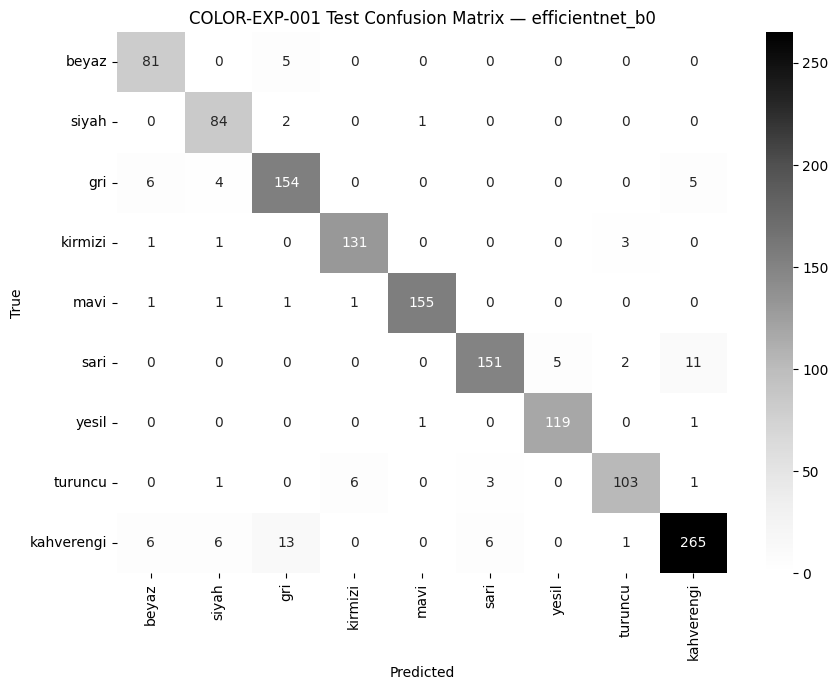

summary_json: /content/drive/MyDrive/anomali-road-safety-ai/runs/vehicle_color/COLOR-EXP-001/COLOR-EXP-001-summary.json
{
  "experiment_id": "COLOR-EXP-001",
  "best_backbone": "efficientnet_b0",
  "best_checkpoint": "/content/drive/MyDrive/anomali-road-safety-ai/models/checkpoints/vehicle_color/COLOR-EXP-001-efficientnet_b0-best.pth",
  "label_map": "/content/drive/MyDrive/anomali-road-safety-ai/models/checkpoints/vehicle_color/COLOR-EXP-001-label-map.json",
  "metadata_csv": "/content/drive/MyDrive/anomali-road-safety-ai/datasets/color_exp_001/metadata/color_exp_001_vcor_ftr_metadata.csv",
  "split_csv": "/content/drive/MyDrive/anomali-road-safety-ai/datasets/color_exp_001/metadata/color_exp_001_split.csv",
  "class_counts": {
    "beyaz": 575,
    "siyah": 579,
    "gri": 1127,
    "kirmizi": 909,
    "mavi": 1060,
    "sari": 1124,
    "yesil": 804,
    "turuncu": 762,
    "kahverengi": 1979
  },
  "train_count": 6242,
  "val_count": 1339,
  "test_count": 1338,
  "val_accuracy": 0.

In [9]:
# Cell 9 — Test evaluation, confusion matrix, and exports
def load_checkpoint_model(checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location=device)
    model = build_model(ckpt['backbone']).to(device)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    return model, ckpt

best_model, best_ckpt = load_checkpoint_model(BEST_CHECKPOINT)
val_eval = evaluate_model(best_model, val_loader)
test_eval = evaluate_model(best_model, test_loader)

print('Validation macro-F1:', val_eval['macro_f1'], 'acc:', val_eval['accuracy'])
print('Test macro-F1:', test_eval['macro_f1'], 'acc:', test_eval['accuracy'])

report_dict = classification_report(
    test_eval['labels'],
    test_eval['preds'],
    labels=list(range(NUM_CLASSES)),
    target_names=FTR_COLOR_LABELS,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).T
report_csv = DRIVE_RUN_ROOT / f'{EXP_ID}-test_classification_report.csv'
report_df.to_csv(report_csv)
display(report_df)

cm = confusion_matrix(test_eval['labels'], test_eval['preds'], labels=list(range(NUM_CLASSES)))
cm_csv = DRIVE_RUN_ROOT / f'{EXP_ID}-test_confusion_matrix.csv'
pd.DataFrame(cm, index=FTR_COLOR_LABELS, columns=FTR_COLOR_LABELS).to_csv(cm_csv)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=FTR_COLOR_LABELS, yticklabels=FTR_COLOR_LABELS, cmap='Greys')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'{EXP_ID} Test Confusion Matrix — {BEST_BACKBONE}')
plt.tight_layout()
cm_png = DRIVE_RUN_ROOT / f'{EXP_ID}-test_confusion_matrix.png'
plt.savefig(cm_png, dpi=180)
plt.show()

pred_rows = []
for label_id, pred_id, probs, path in zip(test_eval['labels'], test_eval['preds'], test_eval['probs'], test_eval['paths']):
    top_idx = int(np.argmax(probs))
    second_idx = int(np.argsort(probs)[-2]) if len(probs) > 1 else top_idx
    pred_rows.append({
        'image_path': path,
        'true_label': id_to_label[int(label_id)],
        'pred_label': id_to_label[int(pred_id)],
        'confidence': float(probs[top_idx]),
        'margin': float(probs[top_idx] - probs[second_idx]),
        'correct': int(label_id == pred_id),
    })
pred_df = pd.DataFrame(pred_rows)
pred_csv = DRIVE_RUN_ROOT / f'{EXP_ID}-test_predictions.csv'
pred_df.to_csv(pred_csv, index=False)

label_map_path = DRIVE_CKPT_ROOT / f'{EXP_ID}-label-map.json'
label_map = {
    'experiment_id': EXP_ID,
    'label_to_id': label_to_id,
    'id_to_label': {str(k): v for k, v in id_to_label.items()},
    'ftr_color_labels': FTR_COLOR_LABELS,
    'color_aliases': COLOR_ALIASES,
    'image_size': IMAGE_SIZE,
    'best_backbone': BEST_BACKBONE,
    'checkpoint': str(BEST_CHECKPOINT),
}
label_map_path.write_text(json.dumps(label_map, indent=2, ensure_ascii=False), encoding='utf-8')

summary_json = DRIVE_RUN_ROOT / f'{EXP_ID}-summary.json'
summary = {
    'experiment_id': EXP_ID,
    'best_backbone': BEST_BACKBONE,
    'best_checkpoint': str(BEST_CHECKPOINT),
    'label_map': str(label_map_path),
    'metadata_csv': str(metadata_csv),
    'split_csv': str(split_csv),
    'class_counts': metadata_df['ftr_color'].value_counts().reindex(FTR_COLOR_LABELS, fill_value=0).to_dict(),
    'train_count': int(len(train_df)),
    'val_count': int(len(val_df)),
    'test_count': int(len(test_df)),
    'val_accuracy': float(val_eval['accuracy']),
    'val_macro_f1': float(val_eval['macro_f1']),
    'test_accuracy': float(test_eval['accuracy']),
    'test_macro_f1': float(test_eval['macro_f1']),
    'artifacts': {
        'backbone_summary_csv': str(summary_path),
        'classification_report_csv': str(report_csv),
        'confusion_matrix_csv': str(cm_csv),
        'confusion_matrix_png': str(cm_png),
        'test_predictions_csv': str(pred_csv),
        'label_map_json': str(label_map_path),
    },
}
summary_json.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding='utf-8')
print('summary_json:', summary_json)
print(json.dumps(summary, indent=2, ensure_ascii=False))


In [ ]:
# Cell 10 — Optional target ROI smoke inference from existing project crops
SMOKE_CROP_CANDIDATES = [
    PROJECT_ROOT / 'runs' / '_archive' / 'plate_ocr_v1_POCR-EXP-001-target-roi-crops' / 'sample_frames',
    PROJECT_ROOT / 'runs' / 'plate_ocr' / 'POCR-EXP-001-target-roi-crops' / 'sample_frames',
    LOCAL_ROOT / 'runs' / '_archive' / 'plate_ocr_v1_POCR-EXP-001-target-roi-crops' / 'sample_frames',
]

def predict_image(path):
    image = Image.open(path).convert('RGB')
    tensor = eval_tf(image).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(best_model(tensor), dim=1).cpu().numpy().reshape(-1)
    top = int(np.argmax(probs))
    second = int(np.argsort(probs)[-2]) if len(probs) > 1 else top
    return {
        'crop_uri': str(path),
        'pred_color': id_to_label[top],
        'confidence': float(probs[top]),
        'margin': float(probs[top] - probs[second]),
        'top3': [
            {'label': id_to_label[int(idx)], 'confidence': float(probs[int(idx)])}
            for idx in np.argsort(probs)[-3:][::-1]
        ],
    }

smoke_dir = next((p for p in SMOKE_CROP_CANDIDATES if p.exists() and any(p.glob('*.jpg'))), None)
if smoke_dir is None:
    print('No existing target ROI crop directory found. Smoke inference skipped.')
else:
    print('Running smoke inference on:', smoke_dir)
    smoke_rows = []
    for path in sorted(smoke_dir.glob('*.jpg')):
        row = predict_image(path)
        # Parse event id prefix conservatively.
        name = path.name
        row['event_id'] = name.split('_TRK-')[0] if '_TRK-' in name else name
        smoke_rows.append(row)
    smoke_df = pd.DataFrame(smoke_rows)
    smoke_csv = DRIVE_RUN_ROOT / f'{EXP_ID}-local_target_roi_smoke_predictions.csv'
    smoke_df.to_csv(smoke_csv, index=False)
    display(smoke_df.head(20))
    if 'event_id' in smoke_df.columns:
        print('Temporal smoke vote by event:')
        display(smoke_df.groupby(['event_id', 'pred_color']).size().reset_index(name='count').sort_values(['event_id', 'count'], ascending=[True, False]))
    print('smoke_csv:', smoke_csv)


In [11]:
# Cell 11 — Markdown run report
report_md = DRIVE_RUN_ROOT / f'{EXP_ID}-run_summary.md'
lines = [
    f'# {EXP_ID} Vehicle Color Classifier Summary',
    '',
    f'- Best backbone: `{BEST_BACKBONE}`',
    f'- Best checkpoint: `{BEST_CHECKPOINT}`',
    f'- Validation macro-F1: `{val_eval["macro_f1"]:.4f}`',
    f'- Validation accuracy: `{val_eval["accuracy"]:.4f}`',
    f'- Test macro-F1: `{test_eval["macro_f1"]:.4f}`',
    f'- Test accuracy: `{test_eval["accuracy"]:.4f}`',
    f'- Train/val/test: `{len(train_df)}/{len(val_df)}/{len(test_df)}`',
    '',
    '## FTR Labels',
    '',
    ', '.join(f'`{x}`' for x in FTR_COLOR_LABELS),
    '',
    '## Important Notes',
    '',
    '- This is a dedicated color classifier for `arac_bilgisi.renk`.',
    '- It should be compared against `VEHINFO-EXP-001` OpenVINO + HSV/Lab baseline before promotion.',
    '- Hue-shifting augmentation is intentionally avoided because it can corrupt the color label.',
    '- If rare colors have low support, add UFPR-VCR or another licensed color dataset before final FTR promotion.',
    '',
    '## Artifacts',
    '',
    f'- Summary JSON: `{summary_json}`',
    f'- Label map: `{label_map_path}`',
    f'- Classification report CSV: `{report_csv}`',
    f'- Confusion matrix PNG: `{cm_png}`',
]
report_md.write_text('\n'.join(lines) + '\n', encoding='utf-8')
print(report_md.read_text())


# COLOR-EXP-001 Vehicle Color Classifier Summary

- Best backbone: `efficientnet_b0`
- Best checkpoint: `/content/drive/MyDrive/anomali-road-safety-ai/models/checkpoints/vehicle_color/COLOR-EXP-001-efficientnet_b0-best.pth`
- Validation macro-F1: `0.9377`
- Validation accuracy: `0.9380`
- Test macro-F1: `0.9297`
- Test accuracy: `0.9290`
- Train/val/test: `6242/1339/1338`

## FTR Labels

`beyaz`, `siyah`, `gri`, `kirmizi`, `mavi`, `sari`, `yesil`, `turuncu`, `kahverengi`

## Important Notes

- This is a dedicated color classifier for `arac_bilgisi.renk`.
- It should be compared against `VEHINFO-EXP-001` OpenVINO + HSV/Lab baseline before promotion.
- Hue-shifting augmentation is intentionally avoided because it can corrupt the color label.
- If rare colors have low support, add UFPR-VCR or another licensed color dataset before final FTR promotion.

## Artifacts

- Summary JSON: `/content/drive/MyDrive/anomali-road-safety-ai/runs/vehicle_color/COLOR-EXP-001/COLOR-EXP-001-summary.json`
-